In [1]:
# imports
import numpy as np
import pandas as pd

# plotting Libraries
import seaborn as sns
import matplotlib.pyplot as plt

# preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer

In [2]:
# Load train data
df_train = pd.read_csv('../data/train.csv')
df_train.head(5)

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
0,0,0.0,2.074329,-0.129425,-1.137418,0.412846,-0.192638,-1.210144,0.110697,-0.263477,...,-0.334701,-0.887840,0.336701,-0.110835,-0.291459,0.207733,-0.076576,-0.059577,1.98,0
1,1,0.0,1.998827,-1.250891,-0.520969,-0.894539,-1.122528,-0.270866,-1.029289,0.050198,...,0.054848,-0.038367,0.133518,-0.461928,-0.465491,-0.464655,-0.009413,-0.038238,84.00,0
2,2,0.0,0.091535,1.004517,-0.223445,-0.435249,0.667548,-0.988351,0.948146,-0.084789,...,-0.326725,-0.803736,0.154495,0.951233,-0.506919,0.085046,0.224458,0.087356,2.69,0
3,3,0.0,1.979649,-0.184949,-1.064206,0.120125,-0.215238,-0.648829,-0.087826,-0.035367,...,-0.095514,-0.079792,0.167701,-0.042939,0.000799,-0.096148,-0.057780,-0.073839,1.00,0
4,4,0.0,1.025898,-0.171827,1.203717,1.243900,-0.636572,1.099074,-0.938651,0.569239,...,0.099157,0.608908,0.027901,-0.262813,0.257834,-0.252829,0.108338,0.021051,1.00,0


Perhaps, we can drop Time feature since it have near zero MI score.

# Data Preprocessing 

We saw in 01_eda.ipynb that all features are scaled except for the 'Time' and the 'Transaction_Amount'.
To keep same magnitute for modeling we will perform scalers for both features.
We will use RobustScaler for the 'Transaction_Amount' column as it have outliers and StandardScaler for the 'Time' column.

In [10]:
# Scaling Time and amount values.
rob_scaler = RobustScaler() # is less prone to outliers
stnd_scaler = StandardScaler()

df_train['scaled_Transaction_Amount'] = rob_scaler.fit_transform(df_train['Transaction_Amount'].values.reshape(-1,1))
df_train['scaled_time'] = stnd_scaler.fit_transform(df_train['Time'].values.reshape(-1,1))

df_train.drop(['Time','Transaction_Amount'], axis=1, inplace = True)

# we have done it, but now we need to place columns at the first and second placee in our dataframe

scaled_amount = df_train['scaled_Transaction_Amount']
scaled_time = df_train['scaled_time']

df_train.drop(['scaled_Transaction_Amount', 'scaled_time'], axis=1, inplace=True)
df_train.insert(0, 'scaled_Transaction_Amount', scaled_amount)
df_train.insert(1, 'scaled_time', scaled_time)

KeyError: 'Transaction_Amount'

All the features are scaled now.

In [11]:
df_train.head()

,scaled_Transaction_Amount,scaled_time,id,feat1,feat2,feat3,feat4,feat5,feat6,feat7,...,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,IsFraud
0,-0.342039,-2.657548,0,2.074329,-0.129425,-1.137418,0.412846,-0.192638,-1.210144,0.110697,...,-0.292969,-0.334701,-0.887840,0.336701,-0.110835,-0.291459,0.207733,-0.076576,-0.059577,0
1,0.881958,-2.657548,1,1.998827,-1.250891,-0.520969,-0.894539,-1.122528,-0.270866,-1.029289,...,0.065717,0.054848,-0.038367,0.133518,-0.461928,-0.465491,-0.464655,-0.009413,-0.038238,0
2,-0.331443,-2.657548,2,0.091535,1.004517,-0.223445,-0.435249,0.667548,-0.988351,0.948146,...,-0.021375,-0.326725,-0.803736,0.154495,0.951233,-0.506919,0.085046,0.224458,0.087356,0
3,-0.356663,-2.657548,3,1.979649,-0.184949,-1.064206,0.120125,-0.215238,-0.648829,-0.087826,...,-0.340089,-0.095514,-0.079792,0.167701,-0.042939,0.000799,-0.096148,-0.057780,-0.073839,0
4,-0.356663,-2.657548,4,1.025898,-0.171827,1.203717,1.243900,-0.636572,1.099074,-0.938651,...,-0.203628,0.099157,0.608908,0.027901,-0.262813,0.257834,-0.252829,0.108338,0.021051,0


Builidng undersample for fit a model

In [14]:
df_train = df_train.sample(frac=1) # shuffle dataframe
 # 1st takee all fraud cases
df_fraud = df_train.loc[df_train['IsFraud']==1]
#  2nd take random non fraud cases for the same rows number (they were shuffeled earlier)
df_nonfraud = df_train.loc[df_train['IsFraud']==0][:269] 
df_balanced_undersample = pd.concat([df_fraud, df_nonfraud]) # concatenate fraud and non fraud parts into one table
df_balanced_undersample = df_balanced_undersample.sample(frac=1, random_state=42) # shuffle them again

df_balanced_undersample.head()

,scaled_Transaction_Amount,scaled_time,id,feat1,feat2,feat3,feat4,feat5,feat6,feat7,...,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,IsFraud
24798,-0.356663,-0.818552,24798,1.296098,0.693445,-1.822246,1.017816,1.272660,-0.252739,0.157800,...,-0.039304,-0.037121,-0.116499,-0.195460,-1.638991,0.765293,-0.275022,0.039955,0.041744,0
140070,-0.098791,1.172310,140070,0.408622,1.011738,0.183321,1.894079,0.331236,-0.667899,0.942603,...,0.135528,0.223341,0.944361,0.008385,0.580149,-1.119291,-0.260375,0.001614,0.033947,1
82924,-0.178182,0.322233,82924,-0.774856,0.639488,1.824284,1.276780,-0.602888,0.827238,-0.599913,...,-0.110452,0.353837,1.113028,-0.098957,0.264700,-0.329979,-0.106869,-0.077663,-0.035398,0
59524,0.225190,-0.013901,59524,-0.567952,1.114949,1.139830,1.873740,0.567603,-0.091246,0.958556,...,-0.088816,-0.299841,-0.818277,0.123879,0.006641,-0.859587,-0.402813,-0.099382,0.172548,1
68362,-0.237427,0.116132,68362,-1.471235,1.526041,0.876781,-0.177352,-0.428941,-0.246850,-0.023997,...,0.080012,-0.161445,-0.498938,0.095511,-0.028939,-0.188816,0.078521,0.140778,-0.041628,0


We have balanced undersample now

C:\Users\tinew\AppData\Local\Temp\ipykernel_6504\3930235759.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsFraud', data=df_train, palette=colors)
C:\Users\tinew\AppData\Local\Temp\ipykernel_6504\3930235759.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsFraud', data=df_balanced_undersample, palette=colors)


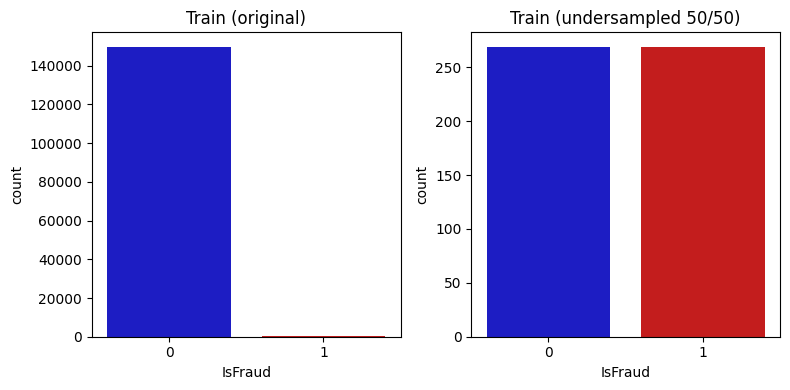

In [ ]:
colors = ["#0101DF", "#DF0101"] # Fraud / non Fraud count plot colors

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
sns.countplot(x='IsFraud', data=df_train, palette=colors)
plt.title('Train (original)')

plt.subplot(1,2,2)
sns.countplot(x='IsFraud', data=df_balanced_undersample, palette=colors)
plt.title('Train (undersampled 50/50)')

plt.tight_layout()

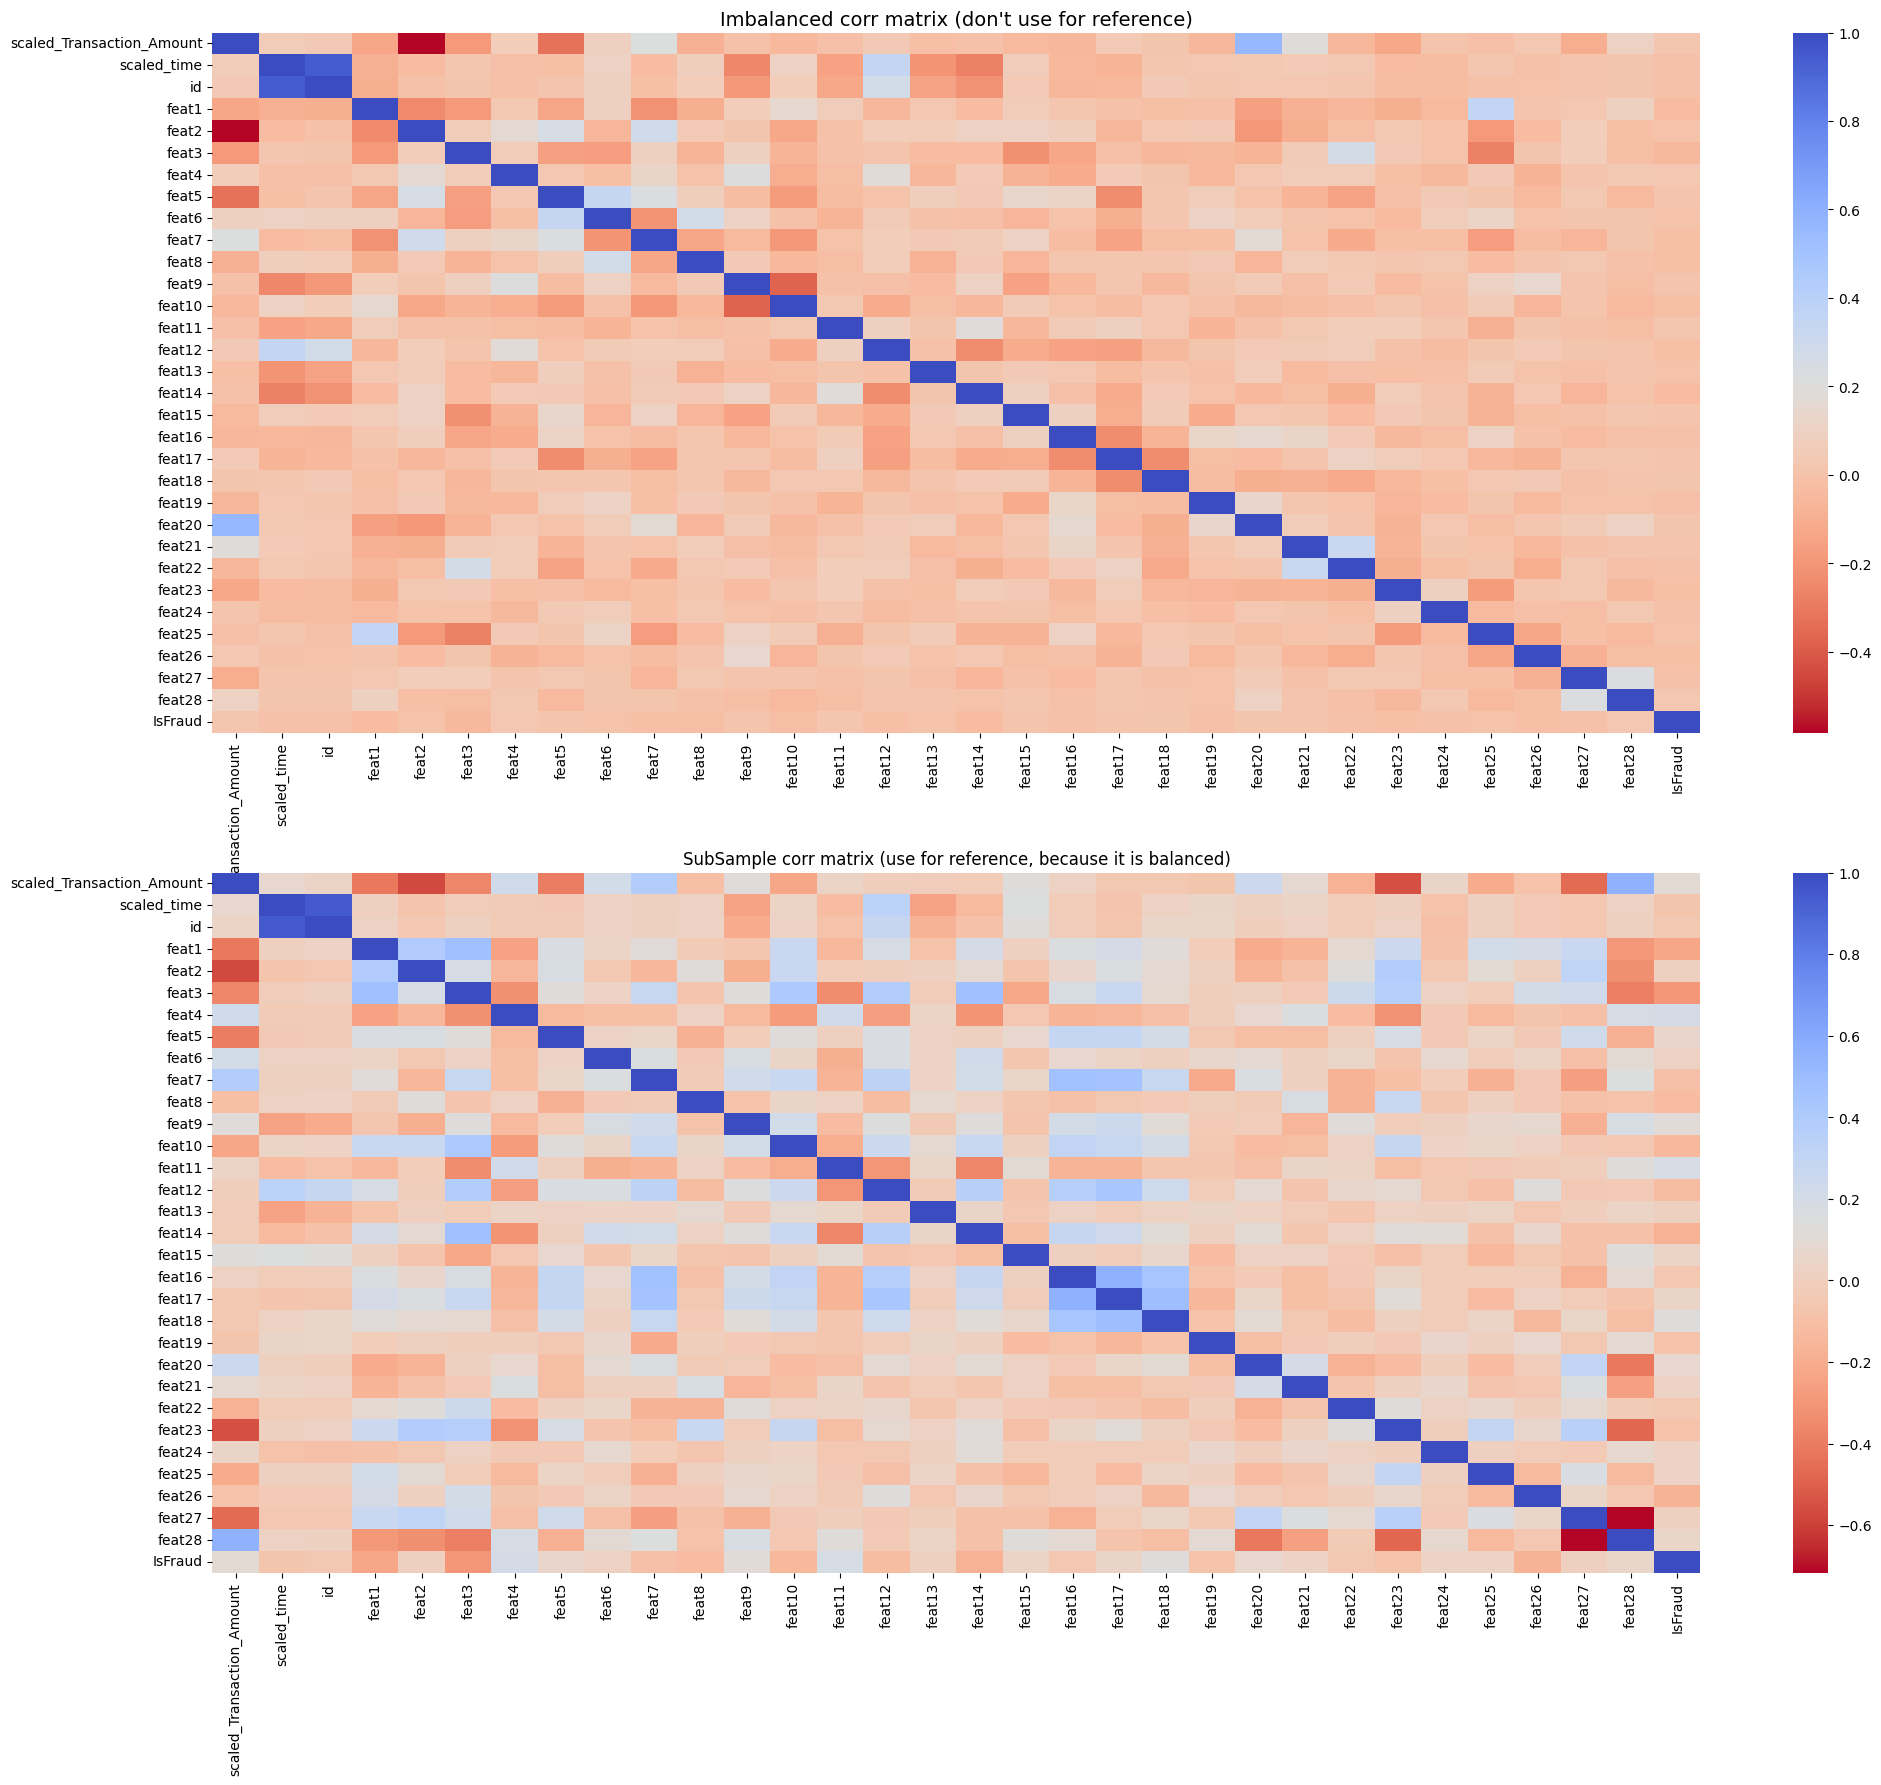

In [22]:
# now lets look at corr matrix for the new and old df (full)
f, (ax1, ax2) = plt.subplots(2,1,figsize=(24,20))

corr = df_train.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title("Imbalanced corr matrix (don't use for reference)", fontsize=14)

sub_sample_corr = df_balanced_undersample.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax2)
ax2.set_title("SubSample corr matrix (use for reference, because it is balanced)")
plt.show()

C:\Users\tinew\AppData\Local\Temp\ipykernel_6504\973100991.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat1', data=df_balanced_undersample, palette=colors, ax=axes[0])
C:\Users\tinew\AppData\Local\Temp\ipykernel_6504\973100991.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat3', data=df_balanced_undersample, palette=colors, ax=axes[1])
C:\Users\tinew\AppData\Local\Temp\ipykernel_6504\973100991.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat26', data=df_balanced_undersa

Text(0.5, 1.0, 'feat4 vs class negative corr')

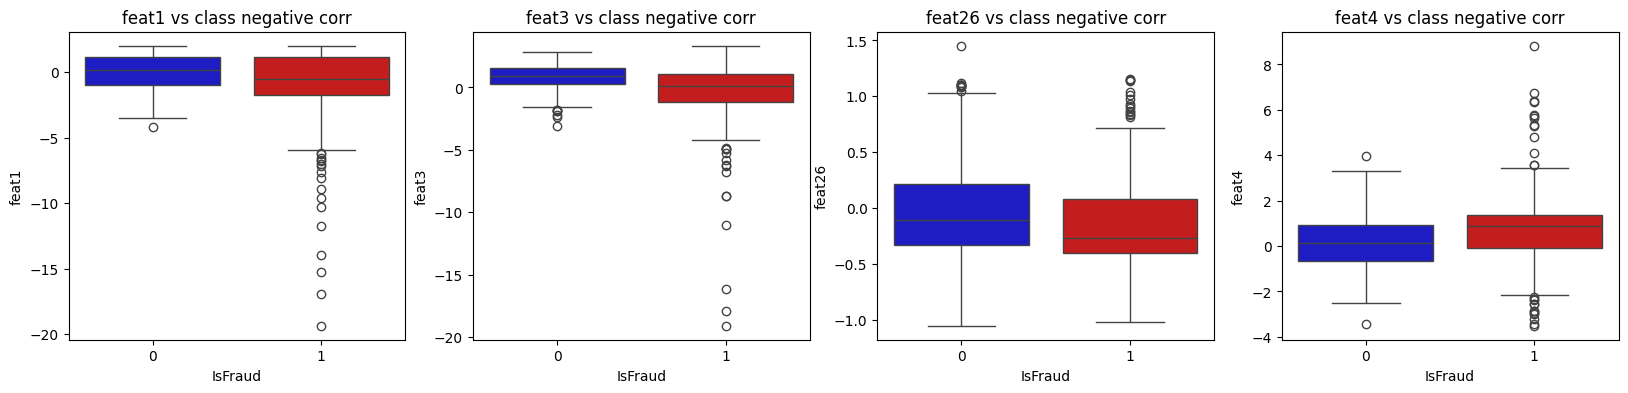

In [24]:
# boxplots for most interested features from the corr matrix
f, axes = plt.subplots(ncols=4, figsize=(20,4))

sns.boxplot(x='IsFraud', y='feat1', data=df_balanced_undersample, palette=colors, ax=axes[0])
axes[0].set_title('feat1 vs class negative corr')

sns.boxplot(x='IsFraud', y='feat3', data=df_balanced_undersample, palette=colors, ax=axes[1])
axes[1].set_title('feat3 vs class negative corr')

sns.boxplot(x='IsFraud', y='feat26', data=df_balanced_undersample, palette=colors, ax=axes[2])
axes[2].set_title('feat26 vs class negative corr')

sns.boxplot(x='IsFraud', y='feat4', data=df_balanced_undersample, palette=colors, ax=axes[3])
axes[3].set_title('feat4 vs class negative corr')

C:\Users\tinew\AppData\Local\Temp\ipykernel_6504\349368425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat4', data=df_balanced_undersample, palette=colors, ax=axes[0])
C:\Users\tinew\AppData\Local\Temp\ipykernel_6504\349368425.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat11', data=df_balanced_undersample, palette=colors, ax=axes[1])
C:\Users\tinew\AppData\Local\Temp\ipykernel_6504\349368425.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat18', data=df_balanced_unders

Text(0.5, 1.0, 'feat15 vs class positive corr')

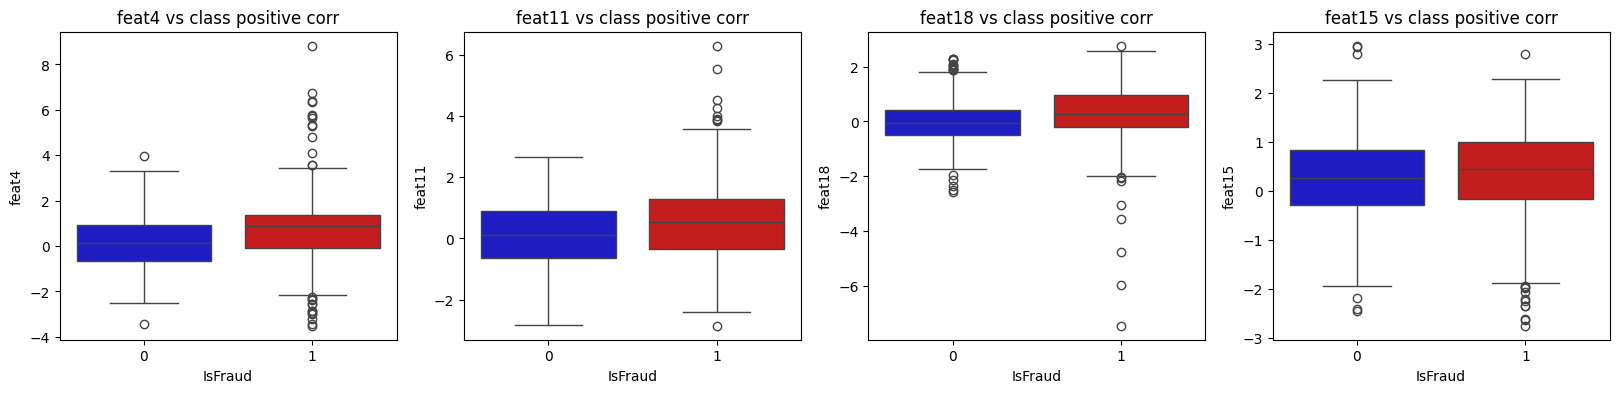

In [26]:
# boxplots for most interested features from the corr matrix
f, axes = plt.subplots(ncols=4, figsize=(20,4))

sns.boxplot(x='IsFraud', y='feat4', data=df_balanced_undersample, palette=colors, ax=axes[0])
axes[0].set_title('feat4 vs class positive corr')

sns.boxplot(x='IsFraud', y='feat11', data=df_balanced_undersample, palette=colors, ax=axes[1])
axes[1].set_title('feat11 vs class positive corr')

sns.boxplot(x='IsFraud', y='feat18', data=df_balanced_undersample, palette=colors, ax=axes[2])
axes[2].set_title('feat18 vs class positive corr')

sns.boxplot(x='IsFraud', y='feat15', data=df_balanced_undersample, palette=colors, ax=axes[3])
axes[3].set_title('feat15 vs class positive corr')

We see a small differences in some correllated features, but nothing outstanding. So, just continue modeling with all the features.

In [ ]:
# Split X and y
X_full = df_train.copy()
X_full = X_full.drop(columns=['id'])
y_full = X_full.pop('IsFraud')

In [ ]:
# Delete? I take all the features.
# other
from sklearn.feature_selection import mutual_info_classif

def make_mi_scores(X,y):
    X = X.copy()
    for colname in X.select_dtypes(['object', 'category']):
        x[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_classif(X,y, discrete_features = discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name='MI Scores', index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

def plot_mi_scores(scores):
    '''Input: pandas series from def make_mi_scores'''
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title('Mutual Information Scores')

mi_scores = make_mi_scores(X_full,y_full)
plot_mi_scores(mi_scores)